In [10]:
#Example of supress warnings for Numpy version out of range (optional)
import warnings
warnings.filterwarnings("ignore", category=Warning)
warnings.simplefilter(action='ignore', category=FutureWarning)

#Some recommended libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV, learning_curve
import seaborn as sns

In [37]:
# load in data
df = pd.DataFrame()
subject_ids = [2301, 2304, 2307, 2308, 2309]
for subject in subject_ids:
    sub_df = pd.read_csv(f"scaledData/{subject}.csv")
    sub_df["id"] = [subject] * len(sub_df["value"])
    df = pd.concat([df, sub_df])
    
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6723 entries, 0 to 1674
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   intensity              6723 non-null   float64
 1   value                  6723 non-null   float64
 2   carbs_g                6723 non-null   float64
 3   prot_g                 6723 non-null   float64
 4   fat_g                  6723 non-null   float64
 5   bolus_dose             6723 non-null   float64
 6   basal_dose             6723 non-null   float64
 7   is_asleep              6723 non-null   bool   
 8   time_of_day_Afternoon  6723 non-null   bool   
 9   time_of_day_Evening    6723 non-null   bool   
 10  time_of_day_Morning    6723 non-null   bool   
 11  time_of_day_Night      6723 non-null   bool   
 12  id                     6723 non-null   int64  
dtypes: bool(5), float64(7), int64(1)
memory usage: 505.5 KB


In [56]:
df = pd.read_csv("scaledData/2301.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663 entries, 0 to 1662
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   intensity              1663 non-null   float64
 1   value                  1663 non-null   float64
 2   carbs_g                1663 non-null   float64
 3   prot_g                 1663 non-null   float64
 4   fat_g                  1663 non-null   float64
 5   bolus_dose             1663 non-null   float64
 6   basal_dose             1663 non-null   float64
 7   is_asleep              1663 non-null   bool   
 8   time_of_day_Afternoon  1663 non-null   bool   
 9   time_of_day_Evening    1663 non-null   bool   
 10  time_of_day_Morning    1663 non-null   bool   
 11  time_of_day_Night      1663 non-null   bool   
dtypes: bool(5), float64(7)
memory usage: 99.2 KB


In [57]:
target = df["value"]
df.drop(columns=["value"], inplace=True)
df.head()

,intensity,carbs_g,prot_g,fat_g,bolus_dose,is_asleep,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,0.221424,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True
1,-0.897371,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True
2,-0.897371,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True
3,-0.897371,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True
4,0.221424,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True


In [58]:
# split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)

In [59]:
rf = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, min_samples_split=5, max_features="sqrt", bootstrap=True)
rf.fit(X_train, y_train)

#Make predictions
y_pred = rf.predict(X_test)

In [60]:
#Evaluate the classifier
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mean_absolute_error, mean_squared_error, r2_score

print(f"Regression Mean Absolute Error: {mae:.2f}")
print(f"Regression Mean Squared Error: {mse:.2f}")
print(f"Regression r2 Score: {r2:.2f}")

Regression Mean Absolute Error: 0.67
Regression Mean Squared Error: 0.74
Regression r2 Score: 0.29


In [63]:
parameters = {
    "max_depth": [None, 3, 5, 8, 10, 15, 20],
    "min_samples_split": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20],
    "max_features": ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(estimator=rf, param_grid=parameters, cv=5)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 3, 'max_features': None, 'min_samples_split': 2}
0.2650765420073795


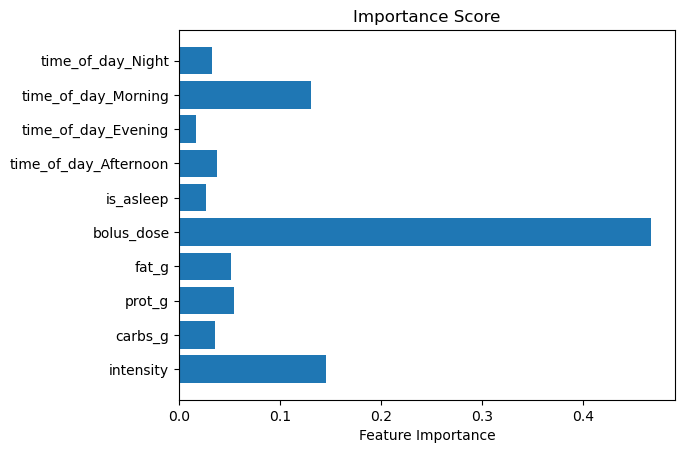

In [61]:
# feature importance plot
importances = rf.feature_importances_
indices = np.argsort(importances)
feature_names = df.columns
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Importance Score")
plt.show()